In [6]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f)

ROOT = Path("..")

wsd_raw      = read_jsonl(ROOT / "logs/wsd_intermediate_10k_20260606-071741/metrics.jsonl")
wsd_beta_raw = read_jsonl(ROOT / "logs/wsd_beta_intermediate_10k_20260606-082147/metrics.jsonl")
cosine_raw   = read_jsonl(ROOT / "logs/cosine_intermediate_10k_20260606-071749/metrics.jsonl")

def split(raw):
    train = raw[raw["train_loss"].notna()].reset_index(drop=True)
    val   = raw[raw["validation_loss"].notna()].reset_index(drop=True) if "validation_loss" in raw.columns else None
    return train, val

wsd_train,      wsd_val      = split(wsd_raw)
wsd_beta_train, wsd_beta_val = split(wsd_beta_raw)
cosine_train,   cosine_val   = split(cosine_raw)

print(f"WSD steps:      {wsd_train['step'].min()} → {wsd_train['step'].max()}")
print(f"WSD-beta steps: {wsd_beta_train['step'].min()} → {wsd_beta_train['step'].max()}")
print(f"Cosine steps:   {cosine_train['step'].min()} → {cosine_train['step'].max()} (incomplete run)")

WSD steps:      5 → 10000
WSD-beta steps: 5 → 10000
Cosine steps:   5 → 5785 (incomplete run)


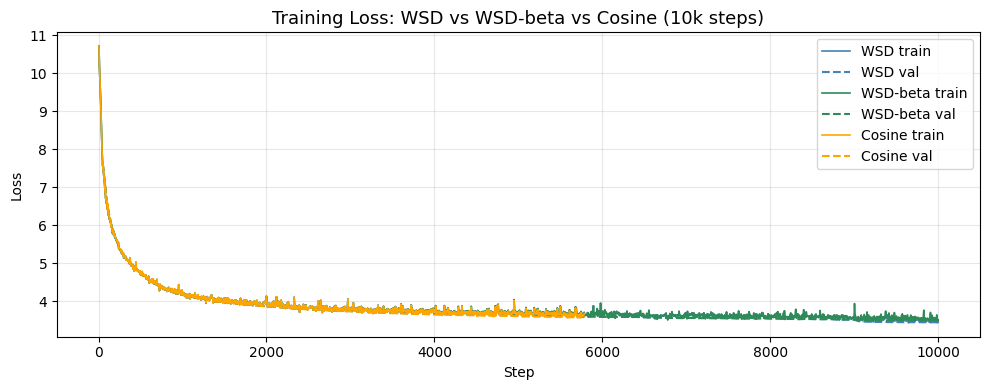

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))

runs = [
    (wsd_train,      wsd_val,      "steelblue", "WSD"),
    (wsd_beta_train, wsd_beta_val, "seagreen",  "WSD-beta"),
    (cosine_train,   cosine_val,   "orange",    "Cosine"),
]

for train_df, val_df, color, name in runs:
    ax.plot(train_df["step"], train_df["train_loss"], color=color, linewidth=1.2, label=f"{name} train")
    if val_df is not None and len(val_df) > 0:
        ax.plot(val_df["step"], val_df["validation_loss"], color=color, linewidth=1.5, linestyle="--", label=f"{name} val")

ax.set_title("Training Loss: WSD vs WSD-beta vs Cosine (10k steps)", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

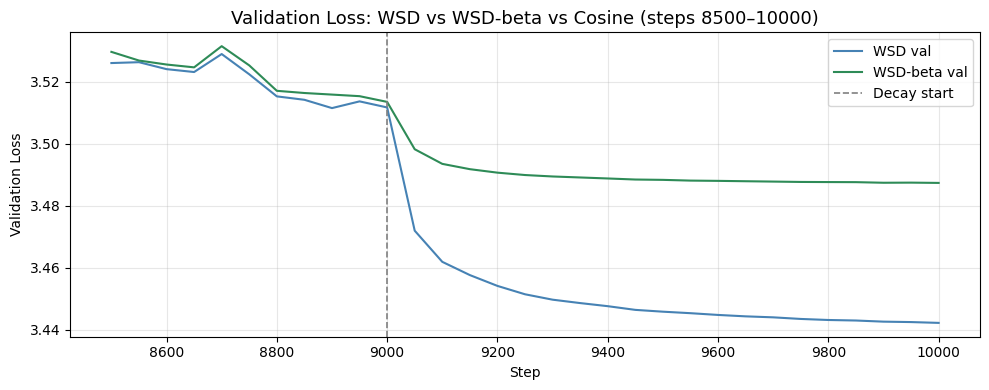

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

runs = [
    (wsd_val,      "steelblue", "WSD"),
    (wsd_beta_val, "seagreen",  "WSD-beta"),
    (cosine_val,   "orange",    "Cosine"),
]

ZOOM_START, ZOOM_END = 8500, 10000
DECAY_START = 9000

for val_df, color, name in runs:
    if val_df is not None and len(val_df) > 0:
        mask = val_df["step"].between(ZOOM_START, ZOOM_END)
        if mask.any():
            ax.plot(val_df.loc[mask, "step"], val_df.loc[mask, "validation_loss"],
                    color=color, linewidth=1.5, linestyle="-", label=f"{name} val")

ax.axvline(DECAY_START, color="gray", linewidth=1.2, linestyle="--", label="Decay start")

ax.set_title(f"Validation Loss: WSD vs WSD-beta vs Cosine (steps {ZOOM_START}–{ZOOM_END})", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

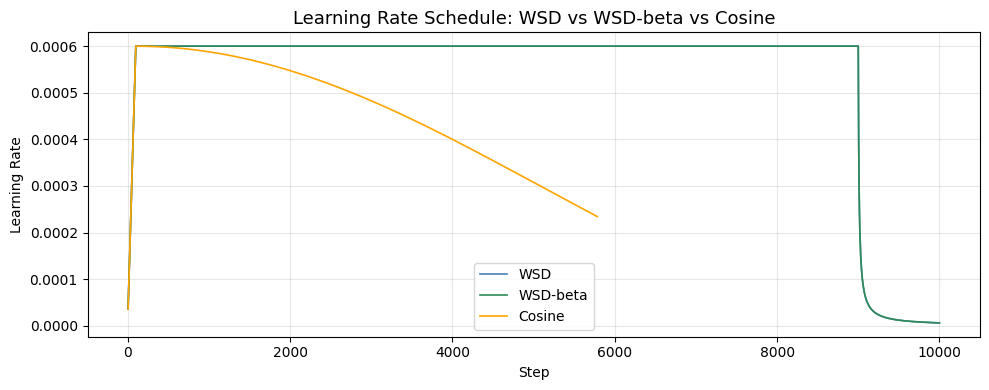

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))

runs = [
    (wsd_train,      "steelblue", "WSD"),
    (wsd_beta_train, "seagreen",  "WSD-beta"),
    (cosine_train,   "orange",    "Cosine"),
]

for train_df, color, name in runs:
    ax.plot(train_df["step"], train_df["learning_rate"], color=color, linewidth=1.2, label=name)

ax.set_title("Learning Rate Schedule: WSD vs WSD-beta vs Cosine", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()